# Discovery cohort CD20^dim^ T cells analysis

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(future)
  library(tidyverse)
  library(ggforce)
  library(patchwork)
  library(cowplot)
  library(ComplexHeatmap)
})

In [ ]:
options(future.globals.maxSize = 1000000 * 1024^2, hpc.ncpus = 16)
plan(multicore, workers = getOption("hpc.ncpus", 1))

# Helper functions

In [ ]:
source("../scripts/plotting.R")

# Load data

### Filtered dataset

QS object generated by running notebooks in `03_annotate`

In [ ]:
seu <- qs::qread(file = "../data/processed/cite_seq/cohort_treatment_naive/annotated/annotated.qs", nthreads = getOption("hpc.ncpus", 1))

### totalVI denoised RNA and ADT data

In [ ]:
rna.denoised <- h5ad.to.seurat(
  file = "../data/processed/cite_seq/cohort_treatment_naive/models/totalvi/totalvi_rna_denoised.h5ad",
  x = "data",
  raw = NULL,
  assay.name = "RNA_denoised"
)

In [ ]:
adt.denoised <- h5ad.to.seurat(
  file = "../data/processed/cite_seq/cohort_treatment_naive/models/totalvi/totalvi_adt_denoised.h5ad",
  x = "data",
  raw = NULL,
  assay.name = "ADT_denoised"
)

In [7]:
seu[["RNA_denoised"]] <- rna.denoised[["RNA_denoised"]]
seu[["ADT_denoised"]] <- adt.denoised[["ADT_denoised"]]

In [8]:
seu

An object of class Seurat 
31865 features across 264512 samples within 5 assays 
Active assay: RNA (26424 features, 4993 variable features)
 3 layers present: data, counts, scale.data
 4 other assays present: ADT, ADTC, RNA_denoised, ADT_denoised
 5 dimensional reductions calculated: pca, integrated.rna, apca, integrated.adt, umap

### Perturbation scores

In [ ]:
meld.stats <- set_names(c("Early", "Late")) %>%
  map(
    .f = function(x) {
      read.table(
        file = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/meld_stats_{x}.tsv"),
        sep = "\t",
        header = TRUE
      )
    }
  )

### Program scores

In [ ]:
gep.usage <- set_names(c("B", "DC", "Mono", "NK", "T")) %>%
  map(
    .f = function(x) {
      mat <- read_tsv(
        file = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/gep/{x}/finalised/usage.tsv"),
        col_names = TRUE,
        show_col_types = FALSE
      ) %>%
        column_to_rownames("...1") %>%
        as.matrix()
      labels <- yaml::read_yaml(glue::glue("../results/tables/cite_seq/cohort_treatment_naive/gep/{x}/finalised/module_labels.yaml"))
      colnames(mat) <- labels[colnames(mat)]
      return(t(mat))
    }
  )

New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`


## Gate CD20^dim^ T cells

In [13]:
# Subset to B cells, T cells and NK cells only
sub <- subset(seu, subset = cluster_main %in% c("B", "NK", "T"))

In [ ]:
data <- FetchData(sub, vars = c("cluster_main", "cluster_coarse", "adtdenoised_ADT-CD3", "adtdenoised_ADT-CD20", "condition"))

# Manual gates selected by inspecting ADT-CD3 vs ADT-CD20 density plots
gate.cd3 <- c(2, 4.5)
gate.cd20 <- c(1.5, 3.5)

# Extract gated barcodes (note restriction to cells annotated as T cells)
gated <- data %>%
  filter(
    cluster_main == "T",
    `adtdenoised_ADT-CD3` >= gate.cd3[1],
    `adtdenoised_ADT-CD3` <= gate.cd3[2],
    `adtdenoised_ADT-CD20` >= gate.cd20[1],
    `adtdenoised_ADT-CD20` <= gate.cd20[2]
  ) %>%
  rownames()

In [23]:
p1 <- ggplot(data = data, mapping = aes(x = `adtdenoised_ADT-CD3`, y = `adtdenoised_ADT-CD20`, color = cluster_main)) +
  scattermore::geom_scattermore(pointsize = 5, alpha = 1, pixels = c(2048, 2048)) +
  geom_vline(xintercept = gate.cd3[1], linetype = "dashed", color = "grey50", linewidth = 0.5) +
  geom_hline(yintercept = gate.cd20[1], linetype = "dashed", color = "grey50", linewidth = 0.5) +
  scale_x_continuous(expand = expansion(mult = c(0, 0.05))) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
  scale_color_manual(values = cluster.pal) +
  labs(title = NULL, x = "CD3", y = "CD20", color = NULL) +
  guides(colour = guide_legend(override.aes = list(size = 5, alpha = 1), ncol = 1)) +
  theme_custom() +
  inset.legend(location = "topright") +
  theme(
    aspect.ratio = 1,
    axis.title = element_text(face = "bold")
  )

In [24]:
p2 <- ggplot(data = data, mapping = aes(x = `adtdenoised_ADT-CD3`, y = `adtdenoised_ADT-CD20`, color = calculate.point.density(`adtdenoised_ADT-CD3`, `adtdenoised_ADT-CD20`, n = 1000, h = 1))) +
  scattermore::geom_scattermore(pointsize = 5, alpha = 1, pixels = c(2048, 2048), show.legend = FALSE) +
  scattermore::geom_scattermore(data = data[gated, ], color = "magenta", pointsize = 5, alpha = 1, pixels = c(2048, 2048)) +
  annotate(geom = "rect", xmin = gate.cd3[1], xmax = gate.cd3[2], ymin = gate.cd20[1], ymax = gate.cd20[2], fill = NA, color = "black", linewidth = 0.5) +
  annotate(geom = "text", x = gate.cd3[2], y = gate.cd20[2] + 0.1, label = expression(bold('CD20'^dim~T~cells)), hjust = 1, vjust = 0, size = 5, fontface = "bold", color = "magenta") +
  scale_x_continuous(expand = expansion(mult = c(0, 0.05))) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
  scale_colour_gradientn(colors = pals::jet(100)) +
  labs(title = NULL, x = "CD3", y = "CD20", color = NULL) +
  theme_custom() +
  inset.legend(location = "topright") +
  theme(
    aspect.ratio = 1,
    axis.title = element_text(face = "bold")
  )

Warning message in is.na(x):
"is.na() applied to non-(list or vector) of type 'expression'"
Warning message in is.na(x):
"is.na() applied to non-(list or vector) of type 'expression'"


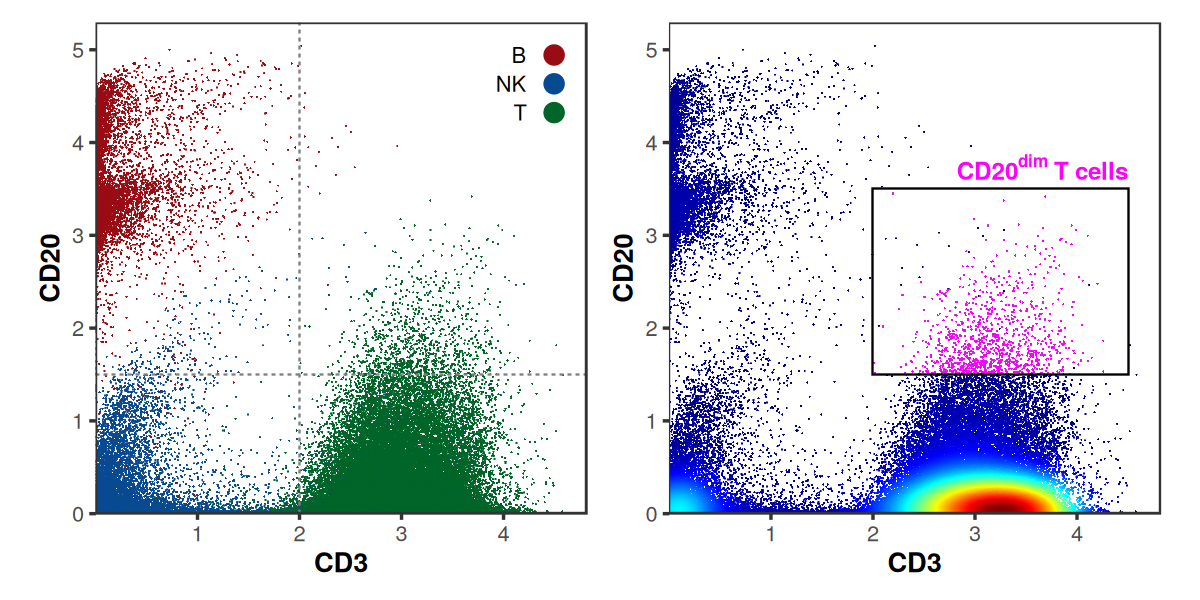

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 5)

plot.combined <- p1 + p2 + plot_layout(ncol = 2)

plot.combined

ggsave(
  plot = plot.combined,
  filename = "../results/plots/cohort_treatment_naive_cd20dim_t_gating.pdf",
  width = 10,
  height = 5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

## Subset to T cells

In [12]:
# Subset to T cells only
sub <- subset(seu, subset = cluster_main == "T")
Idents(sub) <- "cluster_fine"

In [13]:
sub[["GEP"]] <- CreateAssayObject(data = gep.usage[["T"]])

Warning message:
"Layer counts isn't present in the assay object; returning NULL"


# Compare T~c~1-TH signature high cells to gated CD20^dim^ T cells

In [14]:
chosen.gep <- Features(sub[["GEP"]])[c(13, 20, 30)]
chosen.gep

[1] "Th1-like (CXCR3/CCL5/ITGA4)"             
[2] "Cytotoxic Inflammatory (GZMK/EOMES/IFNG)"
[3] "Activation Signalling (IER2/CD69/CD83)"

In [15]:
sub$program_score <- apply(GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)
threshold <- 0.2 # threshold for high vs low program usage
sub$program_high <- if_else(sub$program_score > threshold, "High", "Low")

In [49]:
data <- FetchData(sub, vars = c("cluster_coarse", "program_high")) %>%
  filter(cluster_coarse %in% c("T_CD4_memory", "T_CD8_memory"))

data$gated <- FALSE
data$gated[match(rownames(data), gated)] <- TRUE

contingency <- table("Tc1-TH" = data$program_high, "CD20dim" = data$gated)
contingency

      CD20dim
Tc1-TH FALSE  TRUE
  High  7573    94
  Low  39648   380

In [50]:
stats <- fisher.test(contingency, alternative = "two.sided")
stats


	Fisher's Exact Test for Count Data

data:  contingency
p-value = 0.02778
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.6136946 0.9797121
sample estimates:
odds ratio 
 0.7721565 


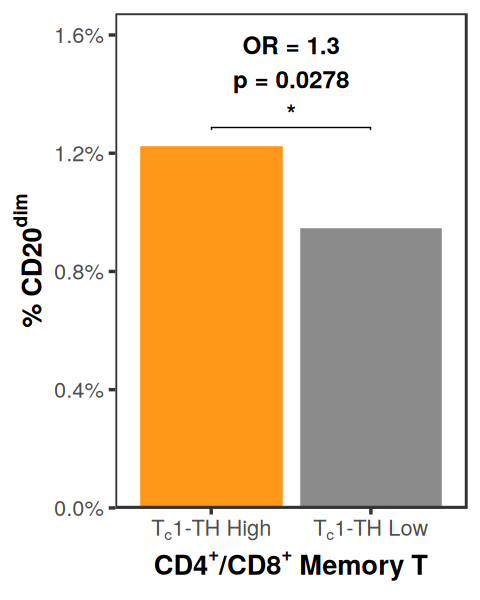

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 5)

data <- (contingency / rowSums(contingency)) %>%
  as.data.frame() %>%
  filter(CD20dim == TRUE)

plot <- ggplot(data = data) +
  geom_col(mapping = aes(x = Tc1.TH, y = Freq, fill = Tc1.TH), color = "white", size = 0.3, alpha = 0.9, show.legend = FALSE) +
  ggpubr::stat_pvalue_manual(
    data = data.frame(
      group1 = "Low",
      group2 = "High",
      y.position = max(data$Freq) * 1.05,
      label = paste0("OR = ", signif(1 / stats$estimate, digits = 3), "\np = ", signif(stats$p, digits = 3), "\n*")
    ),
    tip.length = 0.02,
    bracket.size = 0.3,
    size = 5,
    fontface = "bold"
  ) +
  scale_x_discrete(labels = function(x) parse(text = glue::glue("T[c] * '1-' * TH ~ '{x}'"))) +
  scale_y_continuous(labels = scales::percent_format(), expand = expansion(mult = c(0, 0.3))) +
  scale_fill_manual(values = c("#ff8c00", "grey50")) +
  labs(
    x = expression(bold('CD4'^'+'*'/'*'CD8'^'+'~Memory~T)),
    y = expression(bold('%'~'CD20'^dim))
  ) +
  theme_custom() +
  theme(
    axis.title = element_text(face = "bold")
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/cohort_treatment_naive_tc1th_program_score_cd20dim_bar.pdf",
  width = 4,
  height = 5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Compare CD20 gene and protein expression

In [83]:
data.t <- FetchData(sub, vars = c("rnadenoised_MS4A1", "adtdenoised_ADT-CD20", "cluster_coarse", "program_high")) %>%
  filter(cluster_coarse %in% c("T_CD4_memory", "T_CD8_memory")) %>%
  mutate(group = glue::glue("T[c] * '1-' * TH ~ '{program_high}'")) %>% 
  select(`rnadenoised_MS4A1`, `adtdenoised_ADT-CD20`, group)

data.b <- FetchData(seu, vars = c("rnadenoised_MS4A1", "adtdenoised_ADT-CD20", "cluster_main", "cluster_coarse")) %>%
  filter(cluster_main == "B") %>%
  mutate(group = str_to_sentence(str_remove(string = cluster_coarse, pattern = "^B_"))) %>%
  select(`rnadenoised_MS4A1`, `adtdenoised_ADT-CD20`, group)

data <- bind_rows(data.t, data.b) %>%
  rename(
    `CD20: Surface Protein Expression` = `adtdenoised_ADT-CD20`,
    `CD20: Gene Expression` = `rnadenoised_MS4A1`
  ) %>%
  pivot_longer(
    cols = c(`CD20: Surface Protein Expression`, `CD20: Gene Expression`),
    names_to = "modality",
    values_to = "expression"
  ) %>%
  mutate(
    modality = factor(modality, levels = c("CD20: Surface Protein Expression", "CD20: Gene Expression")),
    group = factor(group, levels = c("Naive", "Memory", "Plasma", "T[c] * '1-' * TH ~ 'High'", "T[c] * '1-' * TH ~ 'Low'"))
  )

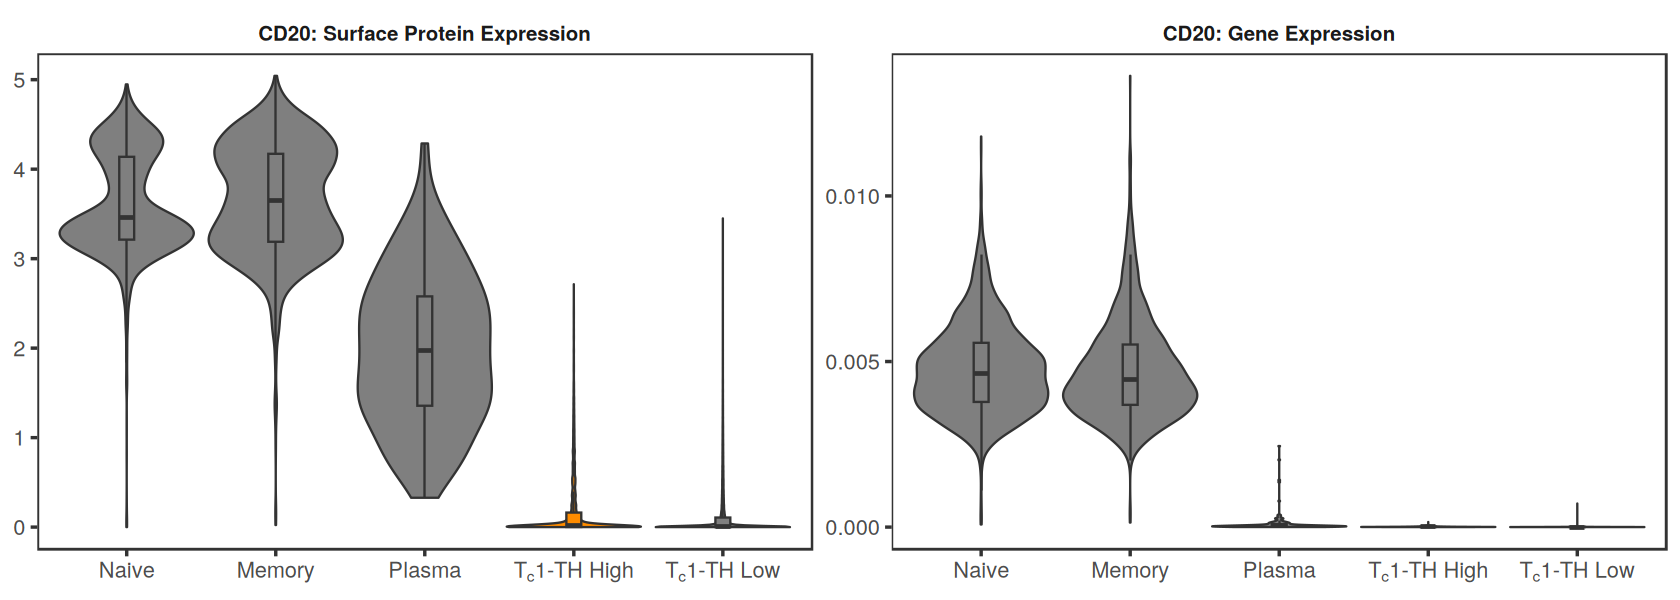

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 5)

plot <- ggplot(data = data, mapping = aes(x = group, y = expression, fill = group)) +
  geom_violin(scale = "width") +
  geom_boxplot(width = 0.1, outliers = FALSE) +
  facet_wrap(~modality, nrow = 1, scales = "free_y") +
  scale_x_discrete(labels = function(x) parse(text = x)) +
  scale_fill_manual(values = c("T[c] * '1-' * TH ~ 'High'" = "#ff8c00", "T[c] * '1-' * TH ~ 'Low'" = "grey50", "Naive" = "grey50", "Memory" = "grey50", "Plasma" = "grey50")) +
  labs(x = NULL, y = NULL) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold"),
    legend.position = "none"
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/cohort_treatment_naive_cd20_violin.pdf",
  width = 14,
  height = 5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

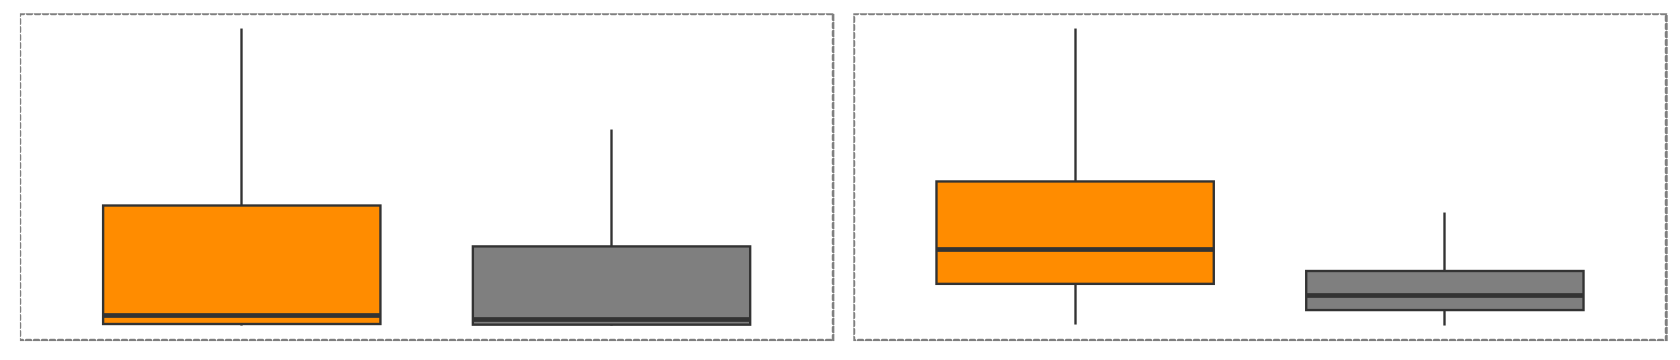

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 3)

plot <- ggplot(data = data %>% filter(!group %in% c("Naive", "Memory", "Plasma")), mapping = aes(x = group, y = expression, fill = group)) +
  geom_boxplot(outliers = FALSE) +
  facet_wrap(~modality, nrow = 1, scales = "free_y") +
  scale_x_discrete(labels = function(x) parse(text = x)) +
  scale_fill_manual(values = c("T[c] * '1-' * TH ~ 'High'" = "#ff8c00", "T[c] * '1-' * TH ~ 'Low'" = "grey50")) +
  labs(x = NULL, y = NULL) +
  theme_custom() +
  theme(
    panel.border = element_rect(colour = "grey50", linetype = "dashed"),
    strip.background = element_blank(),
    strip.text = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "none"
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/cohort_treatment_naive_cd20_boxplot.pdf",
  width = 14,
  height = 3,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Session Info

In [ ]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ceph/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ComplexHeatmap_2.18.0 cowplot_1.1.3         patchwork_1.3.0      
 [4] ggforce_0.4.2         lubridate_1.9.3       forcats_1.0.0        
 [7] stringr_1.5.1         dplyr_1.1.4           purrr_1.0.2          
[10] readr_2.1.5           tidyr_1.3.1           tibble_3.2.1         
[13] ggplot2_3.5.1         tidyverse_2.0.0       future_1.34.0        
[16] Seurat_5.1.0          SeuratObject_5.0.2    sp_2.1-4             

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     shape_1.4.6.1          jsonlite_1.8.9      